In [1]:
from trexdiff import Node, tensor2d, sin, relu, cos
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# time horizon -> how many timesteps
T = 50

# difference btwn. timesteps
dt = 1e-1

# gravity
g = 9.81

# that means total time is T * dt
x0 = [
    Node(tensor2d([[0.0]])),
    Node(tensor2d([[0.0]]))
]

def f(x, u, dt):
    """x_t+1 given x_t, u_t"""

    a = u - g * sin(x[0])
    theta_dot_new = x[1] + dt * a
    theta_new = x[0] + theta_dot_new * dt

    # new state
    return [theta_new, theta_dot_new]


xs = [x0]
us = []

for t in range(T):
    u_val = 2.0
    u = Node(tensor2d([[u_val]]))
    us.append(u)

    xs.append(f(xs[-1], u, dt))

In [3]:
# computes all of the values for all xs
# xs[-1][0].forward()

In [4]:
np.cos(-np.pi)

np.float64(-1.0)

In [5]:
target = Node(tensor2d([[-np.pi]]))
U_LIM = 10

Qf  = 1e4

# target, go UP (i.e. np.pi)
# loss = Qf * (xs[-1][0] - target) * (xs[-1][0] - target)
loss = Qf * (cos(xs[-1][0]) + 1)

# STOP, i.e. velocity = 0
loss += Qf * (xs[-1][1] * xs[-1][1])


# control cost
for u in us:
    # loss += 1e-2 * relu(u * u  - U_LIM ** 2)
    loss += 1e-1 * u * u

In [6]:
# learning rate
mu = 7.5e-5
losses = []
N = 50_000

for i in range(N):
    loss.zerograd() # zeros the gradients
    loss.forward()
    loss.backward()

    if i % 1000 == 0:
        print(f'i={i}, loss={loss.val[0,0]:.3f}')
    
    for u in us:
        u.val -= mu * u.grad

    losses.append(loss.val[0,0])

i=0, loss=19320.999
i=1000, loss=1403.057
i=2000, loss=567.680
i=3000, loss=268.507
i=4000, loss=159.316
i=5000, loss=119.068
i=6000, loss=103.655
i=7000, loss=97.328
i=8000, loss=94.329
i=9000, loss=92.550
i=10000, loss=91.235
i=11000, loss=90.117
i=12000, loss=89.101
i=13000, loss=88.155
i=14000, loss=87.264
i=15000, loss=86.422
i=16000, loss=85.623
i=17000, loss=84.865
i=18000, loss=84.143
i=19000, loss=83.454
i=20000, loss=82.796
i=21000, loss=82.167
i=22000, loss=81.564
i=23000, loss=80.985
i=24000, loss=80.429
i=25000, loss=79.894
i=26000, loss=79.379
i=27000, loss=78.882
i=28000, loss=78.403
i=29000, loss=77.941
i=30000, loss=77.494
i=31000, loss=77.062
i=32000, loss=76.645
i=33000, loss=76.240
i=34000, loss=75.848
i=35000, loss=75.469
i=36000, loss=75.101
i=37000, loss=74.744
i=38000, loss=74.398
i=39000, loss=74.063
i=40000, loss=73.737
i=41000, loss=73.420
i=42000, loss=73.113
i=43000, loss=72.814
i=44000, loss=72.524
i=45000, loss=72.242
i=46000, loss=71.968
i=47000, loss=71

In [7]:
# plt.plot(range(N), losses)


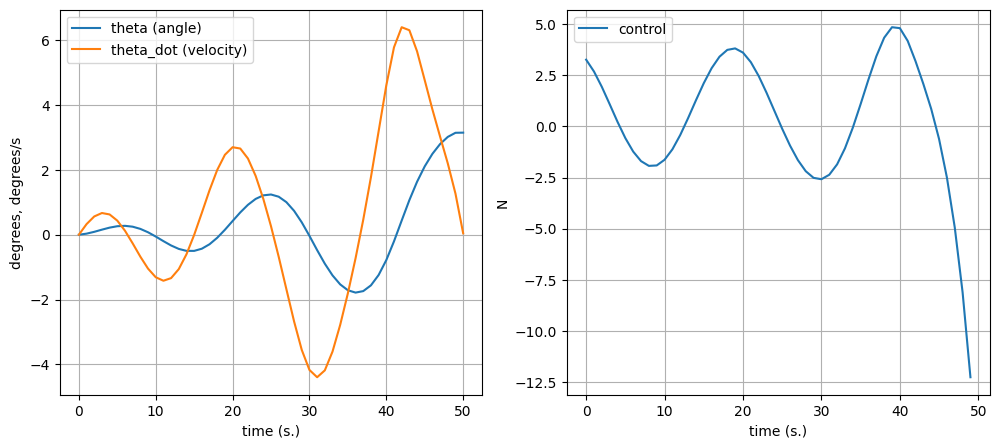

In [8]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

# left - theta, theta_dot
ax[0].plot(range(T + 1), [x[0].val[0,0] for x in xs], label='theta (angle)')
ax[0].plot(range(T + 1), [x[1].val[0,0] for x in xs], label='theta_dot (velocity)')
ax[0].grid()
ax[0].set_xlabel('time (s.)')
ax[0].set_ylabel('degrees, degrees/s')
ax[0].legend()

# right - controls
ax[1].plot(range(T), [u.val[0,0] for u in us], label='control')
ax[1].grid()
ax[1].set_xlabel('time (s.)')
ax[1].set_ylabel('N')
ax[1].legend()

In [9]:
import matplotlib.animation as animation
import os
from IPython.display import HTML, display

L = 1.0  # pendulum arm length
thetas = [
    x[0].val[0,0] for x in xs
]

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.set_aspect('equal')
ax.grid(alpha=0.3)
ax.set_title("Pendulum (optimal control)")

rod,       = ax.plot([], [], 'k-', lw=2)
bob,       = ax.plot([], [], 'o', color='steelblue', ms=14)
pivot,     = ax.plot([0], [0], 'k.', ms=8)
time_text  = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=9)

# hold final frame for 1 s (20 extra frames at 50 ms each) before looping
HOLD_FRAMES = 20
padded_thetas = thetas + [thetas[-1]] * HOLD_FRAMES

def _init():
    rod.set_data([], [])
    bob.set_data([], [])
    time_text.set_text('')
    return rod, bob, time_text

def _animate(i):
    theta = padded_thetas[i]
    bx = L * np.sin(theta)
    by = -L * np.cos(theta)
    rod.set_data([0, bx], [0, by])
    bob.set_data([bx], [by])
    step = min(i, len(thetas) - 1)
    time_text.set_text(f't = {step} steps')
    return rod, bob, time_text

ani = animation.FuncAnimation(
    fig, _animate, init_func=_init,
    frames=len(padded_thetas), interval=50, blit=True
)

os.makedirs("figures", exist_ok=True)
out_path = "figures/pendulum.gif"
ani.save(out_path, writer=animation.PillowWriter(fps=20))
print(f"Saved animation")

display(HTML(ani.to_jshtml()))
plt.close(fig)


Saved animation
